mambajs 0.21.1

Process pip requirements ...

Requirement numpy already handled by conda/micromamba/mamba.
Requirement matplotlib already handled by conda/micromamba/mamba.
Figura salva: aliasing_adveccao_numerica.png


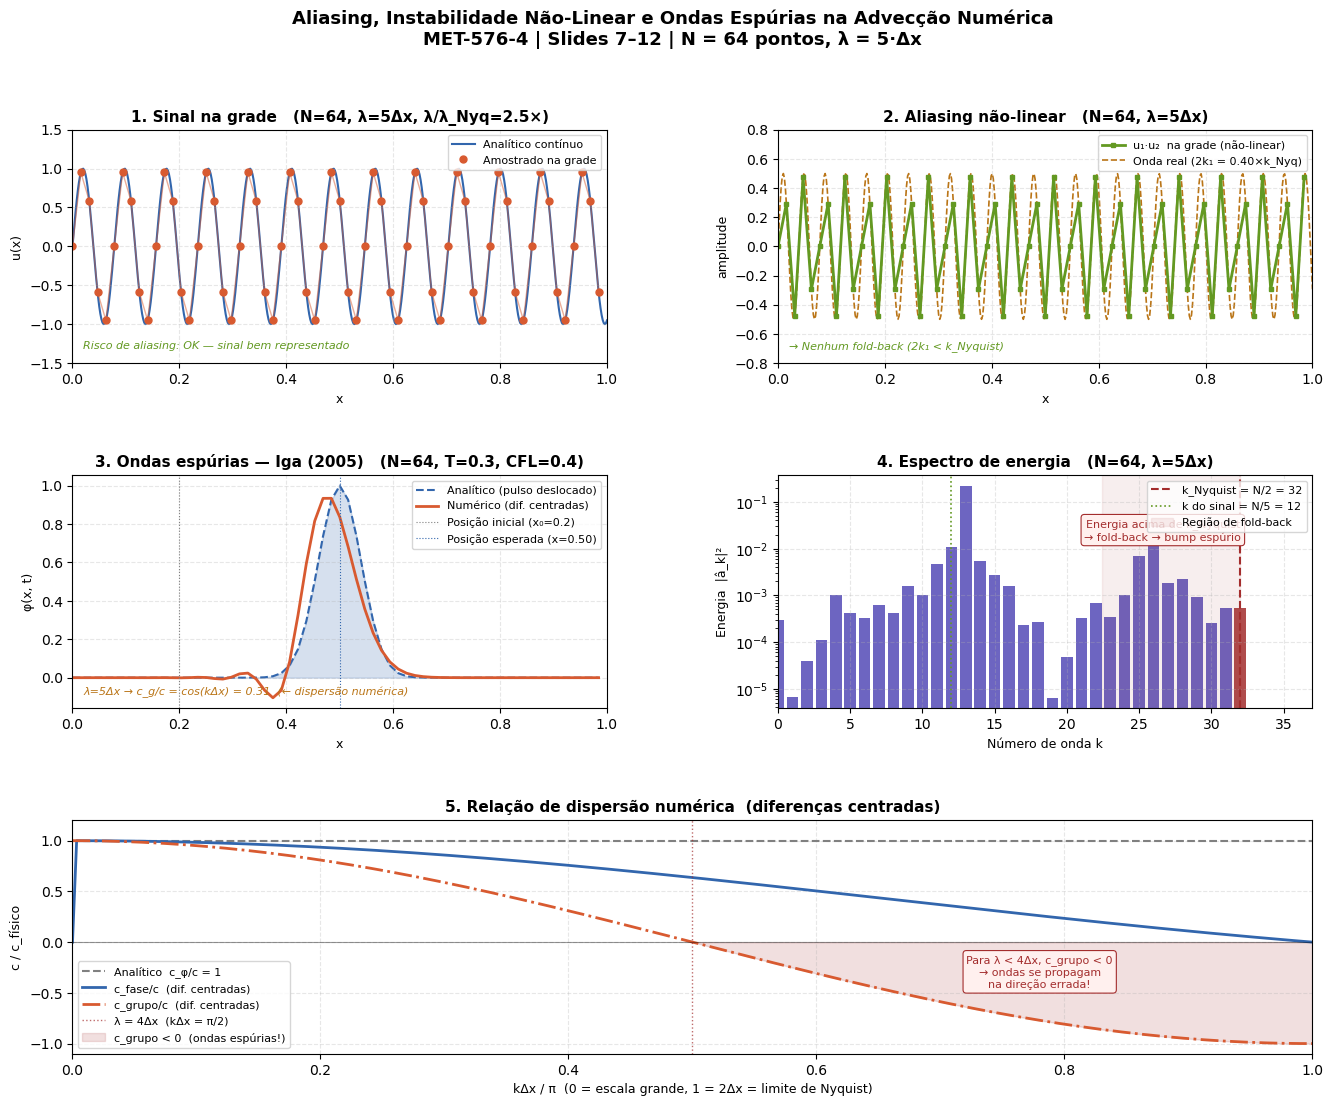

In [1]:
"""
=============================================================================
  Aliasing, Instabilidade Não-Linear e Ondas Espúrias em Advecção Numérica
  MET-576-4 | Fontes de Erros nos Modelos de Previsões Numéricas
  Slides 7–12: Discretização da Dinâmica
=============================================================================

Este script demonstra 4 fenômenos abordados nos slides:
  1. Representação de sinais na grade (critério de Nyquist)
  2. Aliasing não-linear (fold-back de energia)
  3. Ondas espúrias na advecção (experimento de Iga 2005)
  4. Espectro de energia e o "bump" espúrio

Dependências:
    pip install numpy matplotlib

Uso:
    python aliasing_adveccao_numerica.py
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


# =============================================================================
# CONFIGURAÇÃO GLOBAL
# =============================================================================

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "grid.linestyle":   "--",
    "font.family":      "DejaVu Sans",
    "font.size":        10,
    "axes.titlesize":   11,
    "axes.titleweight": "bold",
    "axes.labelsize":   9,
})

BLUE   = "#3266ad"
ORANGE = "#d85a30"
GREEN  = "#639922"
AMBER  = "#ba7517"
PURPLE = "#534ab7"
RED    = "#a32d2d"


# =============================================================================
# 1. SINAL NA GRADE — CRITÉRIO DE NYQUIST
# =============================================================================

def plot_sinal_na_grade(ax, N=32, k_mult=4):
    """
    Compara o sinal analítico contínuo com o sinal amostrado na grade.

    O critério de Nyquist diz que precisamos de pelo menos 2 pontos por
    comprimento de onda (λ ≥ 2·Δx). Abaixo disso ocorre aliasing severo.

    Parâmetros
    ----------
    N      : número de pontos na grade
    k_mult : comprimento de onda em múltiplos de Δx (ex: 4 → λ = 4·Δx)
    """
    dx     = 1.0 / N
    x_grid = np.linspace(0, 1, N, endpoint=False)
    x_fine = np.linspace(0, 1, 500)

    k      = 2 * np.pi / (k_mult * dx)   # número de onda do sinal
    signal_grid = np.sin(k * x_grid)
    signal_fine = np.sin(k * x_fine)

    nyquist_ratio = k_mult / 2.0          # razão λ / λ_mín (Nyquist = 1.0)

    ax.plot(x_fine, signal_fine, color=BLUE,   lw=1.5, label="Analítico contínuo",  zorder=1)
    ax.plot(x_grid, signal_grid, color=ORANGE, lw=0,   label="Amostrado na grade",
            marker="o", ms=5, zorder=2)
    ax.plot(x_grid, signal_grid, color=ORANGE, lw=1.0, alpha=0.5, zorder=2)

    # Marca o limite de Nyquist (2 pontos por onda)
    if k_mult <= 4:
        ax.set_facecolor("#fff8f6")

    ax.set_xlim(0, 1)
    ax.set_ylim(-1.5, 1.5)
    ax.set_title(f"1. Sinal na grade   (N={N}, λ={k_mult}Δx, λ/λ_Nyq={nyquist_ratio:.1f}×)")
    ax.set_xlabel("x")
    ax.set_ylabel("u(x)")
    ax.legend(loc="upper right", fontsize=8)

    status = ("CRÍTICO — aliasing severo!" if k_mult <= 2 else
              "ALTO — próximo do limite de Nyquist" if k_mult <= 4 else
              "OK — sinal bem representado")
    ax.annotate(f"Risco de aliasing: {status}",
                xy=(0.02, 0.06), xycoords="axes fraction",
                fontsize=8, color=RED if k_mult <= 4 else GREEN,
                fontstyle="italic")


# =============================================================================
# 2. ALIASING NÃO-LINEAR — FOLD-BACK DE ENERGIA
# =============================================================================

def plot_aliasing_naolinear(ax, N=32, k_mult=4):
    """
    Demonstra o aliasing gerado pelo termo não-linear u·∂u/∂x.

    Quando u₁ = sin(k₁x) e u₂ = cos(k₁x) interagem via produto,
    eles geram energia em k₁ + k₁ = 2k₁. Se 2k₁ > k_Nyquist = π/Δx,
    essa energia "dobra de volta" para comprimentos de onda menores.

    Isso corresponde ao aliasing descrito no slide 13.
    """
    dx     = 1.0 / N
    x_grid = np.linspace(0, 1, N, endpoint=False)
    x_fine = np.linspace(0, 1, 500)

    k1 = 2 * np.pi / (k_mult * dx)

    # Dois modos que interagem pelo termo não-linear
    u1 = np.sin(k1 * x_grid)
    u2 = np.cos(k1 * x_grid)

    # Produto não-linear: sin(k)·cos(k) = 0.5·sin(2k)
    # Se 2k > k_Nyquist, energia dobra para k_alias = 2π/Δx - 2k
    nao_linear = u1 * u2

    k_nyquist  = np.pi / dx
    k_total    = 2 * k1
    k_alias    = k_total - k_nyquist if k_total > k_nyquist else k_total

    # Sinal "real" (energia que deveria ir para 2k₁)
    alias_fine = 0.5 * np.sin(k_total * x_fine)

    # Onda alias (energia que aparece na grade — fold-back)
    fold_back  = 0.5 * np.sin(k_alias * x_grid)

    ax.plot(x_grid, nao_linear, color=GREEN, lw=2,
            marker="s", ms=3, label="u₁·u₂  na grade (não-linear)", zorder=2)
    ax.plot(x_fine, alias_fine, color=AMBER,  lw=1.2, ls="--",
            label=f"Onda real (2k₁ = {k_total/(2*np.pi)*dx:.2f}×k_Nyq)", zorder=1)
    if k_total > k_nyquist:
        ax.plot(x_grid, fold_back, color=RED, lw=1.8, ls=":",
                label=f"Fold-back (k_alias) ← energia espúria", zorder=3)

    ax.set_xlim(0, 1)
    ax.set_ylim(-0.8, 0.8)
    ax.set_title(f"2. Aliasing não-linear   (N={N}, λ={k_mult}Δx)")
    ax.set_xlabel("x")
    ax.set_ylabel("amplitude")
    ax.legend(loc="upper right", fontsize=8)

    fold_msg = ("→ Fold-back ativo: energia espúria aparece na grade!" if k_total > k_nyquist
                else "→ Nenhum fold-back (2k₁ < k_Nyquist)")
    ax.annotate(fold_msg, xy=(0.02, 0.06), xycoords="axes fraction",
                fontsize=8, color=RED if k_total > k_nyquist else GREEN,
                fontstyle="italic")


# =============================================================================
# 3. ONDAS ESPÚRIAS NA ADVECÇÃO (Iga 2005)
# =============================================================================

def adveccao_centrada_rk4(phi, c, dt, dx):
    """
    Um passo de advecção linear 1D com:
      - Diferenças finitas centradas em espaço (2ª ordem)
      - Runge-Kutta de 4ª ordem em tempo

    A equação é:  ∂φ/∂t + c·∂φ/∂x = 0

    As diferenças centradas introduzem erro de dispersão: modos de pequena
    escala (λ ≈ 2Δx) propagam-se mais devagar — ou até na direção oposta!
    Isso gera as "ondas espúrias" de Iga (2005).
    """
    N = len(phi)

    def L(f):
        # Derivada centrada com condição de contorno periódica
        fp1 = np.roll(f, -1)   # f[i+1]
        fm1 = np.roll(f,  1)   # f[i-1]
        return -c * (fp1 - fm1) / (2 * dx)

    # Runge-Kutta 4
    k1 = L(phi)
    k2 = L(phi + 0.5 * dt * k1)
    k3 = L(phi + 0.5 * dt * k2)
    k4 = L(phi + dt * k3)

    return phi + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)


def plot_ondas_espurias(ax, N=64, k_mult=6):
    """
    Reproduz o experimento de Iga (2005) dos slides 9–12.

    Um pulso gaussiano é advectado com c=1 por t=0.3.
    A solução numérica (diferenças centradas) gera ondas espúrias
    que se propagam na direção OPOSTA ao vento.

    As pequenas escalas (λ ≈ 2Δx) têm velocidade de grupo:
        c_g / c = cos(kΔx)
    que se torna negativa para k·Δx > π/2 (λ < 4Δx).
    """
    dx = 1.0 / N
    x  = np.linspace(0, 1, N, endpoint=False)

    c   = 1.0
    dt  = 0.4 * dx / c            # CFL = 0.4
    T   = 0.3                     # tempo de integração
    n_steps = int(T / dt)

    # Condição inicial: pulso gaussiano centrado em x=0.2
    sigma = 0.04
    x0    = 0.2
    phi0  = np.exp(-((x - x0)**2) / (2 * sigma**2))

    # Integração numérica
    phi = phi0.copy()
    for _ in range(n_steps):
        phi = adveccao_centrada_rk4(phi, c, dt, dx)

    # Solução analítica: desloca o pulso por c·T
    x_true = (x0 + c * T) % 1.0
    phi_true = np.exp(-((x - x_true)**2) / (2 * sigma**2))

    # Erro de fase para o modo dominante
    kdom        = 2 * np.pi / (k_mult * dx)
    c_num_phase = np.sinc(kdom * dx / np.pi) if kdom * dx < np.pi else 0
    # velocidade de grupo numérica para diferenças centradas
    # c_g/c = cos(k·Δx)
    c_g_ratio   = np.cos(kdom * dx)

    ax.fill_between(x, phi_true, alpha=0.2, color=BLUE)
    ax.plot(x, phi_true, color=BLUE,   lw=1.5, ls="--", label="Analítico (pulso deslocado)", zorder=1)
    ax.plot(x, phi,      color=ORANGE, lw=2.0,           label="Numérico (dif. centradas)",   zorder=2)
    ax.axvline(x=x0,     color="gray",  lw=0.8, ls=":",  label=f"Posição inicial (x₀={x0})")
    ax.axvline(x=x_true, color=BLUE,   lw=0.8, ls=":",  label=f"Posição esperada (x={x_true:.2f})")

    ax.set_xlim(0, 1)
    ax.set_title(f"3. Ondas espúrias — Iga (2005)   (N={N}, T={T}, CFL={0.4})")
    ax.set_xlabel("x")
    ax.set_ylabel("φ(x, t)")
    ax.legend(loc="upper right", fontsize=8)

    ax.annotate(
        f"λ={k_mult}Δx → c_g/c = cos(kΔx) = {c_g_ratio:.2f}  "
        f"({'↺ propagação negativa!' if c_g_ratio < 0 else '← dispersão numérica'})",
        xy=(0.02, 0.06), xycoords="axes fraction",
        fontsize=8, color=RED if c_g_ratio < 0 else AMBER, fontstyle="italic"
    )


# =============================================================================
# 4. ESPECTRO DE ENERGIA — BUMP ESPÚRIO
# =============================================================================

def plot_espectro(ax, N=64, k_mult=4):
    """
    Computa e plota o espectro de energia (via DFT) de um sinal composto.

    Ilustra o gráfico do slide 17 (ERA5 vs simulações): energia acima do
    limite de Nyquist não some — é redobrada (fold-back) para números de
    onda menores, criando um "bump" espúrio nas escalas de 2Δx–4Δx.
    """
    dx     = 1.0 / N
    x_grid = np.linspace(0, 1, N, endpoint=False)

    k1 = 2 * np.pi / (k_mult * dx)

    # Sinal com dois modos + ruído de pequena escala
    signal = (np.sin(k1 * x_grid)
              + 0.4 * np.sin(3 * k1 * x_grid)
              + 0.15 * np.random.default_rng(42).standard_normal(N))

    # DFT e espectro de energia (apenas metade positiva)
    fft_coef = np.fft.rfft(signal) / N
    ks       = np.arange(len(fft_coef))
    energy   = np.abs(fft_coef)**2

    k_nyquist = N // 2

    # Cores: vermelho para o modo de Nyquist, azul para os demais
    colors = [RED if k == k_nyquist else PURPLE for k in ks]

    ax.bar(ks, energy, color=colors, alpha=0.85, width=0.8)
    ax.axvline(k_nyquist, color=RED,  lw=1.5, ls="--", label=f"k_Nyquist = N/2 = {k_nyquist}")
    ax.axvline(N // k_mult, color=GREEN, lw=1.2, ls=":",
               label=f"k do sinal = N/{k_mult} = {N//k_mult}")

    # Marca a região de aliasing (energia dobra de volta)
    ax.axvspan(k_nyquist * 0.7, k_nyquist, alpha=0.08, color=RED,
               label="Região de fold-back")

    ax.set_xlim(0, k_nyquist + 5)
    ax.set_title(f"4. Espectro de energia   (N={N}, λ={k_mult}Δx)")
    ax.set_xlabel("Número de onda k")
    ax.set_ylabel("Energia  |â_k|²")
    ax.legend(loc="upper right", fontsize=8)
    ax.set_yscale("log")

    ax.annotate(
        "Energia acima de k_Nyquist\n→ fold-back → bump espúrio",
        xy=(0.72, 0.72), xycoords="axes fraction",
        fontsize=8, color=RED, ha="center",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#fff0ee", edgecolor=RED, lw=0.8)
    )


# =============================================================================
# 5. RELAÇÃO DE DISPERSÃO NUMÉRICA — Erro de fase e velocidade de grupo
# =============================================================================

def plot_dispersao(ax):
    """
    Plota a relação de dispersão das diferenças finitas centradas vs analítica.

    Velocidade de fase numérica:   c_φ/c = sin(kΔx) / (kΔx)
    Velocidade de grupo numérica:  c_g/c = cos(kΔx)

    Para kΔx → π (λ → 2Δx), a velocidade de grupo se torna negativa:
    as ondas curtas propagam-se na direção oposta ao vento → ondas espúrias!
    """
    k_dx = np.linspace(0, np.pi, 300)   # kΔx de 0 a π

    c_phase_num = np.sin(k_dx) / np.maximum(k_dx, 1e-12)   # c_φ/c numérica
    c_group_num = np.cos(k_dx)                               # c_g/c numérica
    c_analytic  = np.ones_like(k_dx)                         # c_φ/c = 1 (analítico)

    ax.plot(k_dx / np.pi, c_analytic,  color="gray",   lw=1.5, ls="--",
            label="Analítico  c_φ/c = 1")
    ax.plot(k_dx / np.pi, c_phase_num, color=BLUE,     lw=2.0,
            label="c_fase/c  (dif. centradas)")
    ax.plot(k_dx / np.pi, c_group_num, color=ORANGE,   lw=2.0, ls="-.",
            label="c_grupo/c  (dif. centradas)")

    ax.axhline(0, color="black", lw=0.8, alpha=0.4)
    ax.axvline(0.5, color=RED, lw=1.0, ls=":", alpha=0.7,
               label="λ = 4Δx  (kΔx = π/2)")

    # Região onde c_g < 0 (ondas espúrias)
    k_neg  = k_dx[k_dx > np.pi/2] / np.pi
    c_neg  = np.cos(k_dx[k_dx > np.pi/2])
    ax.fill_between(k_neg, c_neg, 0, alpha=0.15, color=RED,
                    label="c_grupo < 0  (ondas espúrias!)")

    ax.set_xlim(0, 1)
    ax.set_ylim(-1.1, 1.2)
    ax.set_title("5. Relação de dispersão numérica  (diferenças centradas)")
    ax.set_xlabel("kΔx / π  (0 = escala grande, 1 = 2Δx = limite de Nyquist)")
    ax.set_ylabel("c / c_físico")
    ax.legend(loc="lower left", fontsize=8)

    ax.annotate("Para λ < 4Δx, c_grupo < 0\n→ ondas se propagam\nna direção errada!",
                xy=(0.78, -0.45), xycoords="data", fontsize=8, color=RED,
                ha="center",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="#fff0ee", edgecolor=RED, lw=0.8))


# =============================================================================
# FIGURA PRINCIPAL
# =============================================================================

def main():
    # Parâmetros ajustáveis — mude aqui para explorar diferentes cenários
    N       = 64    # pontos na grade (tente 16, 32, 64, 128)
    K_MULT  = 5     # λ em múltiplos de Δx (tente 2, 4, 6, 10)

    fig = plt.figure(figsize=(16, 12))
    fig.suptitle(
        "Aliasing, Instabilidade Não-Linear e Ondas Espúrias na Advecção Numérica\n"
        f"MET-576-4 | Slides 7–12 | N = {N} pontos, λ = {K_MULT}·Δx",
        fontsize=13, fontweight="bold", y=0.98
    )

    gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.48, wspace=0.32)

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[1, 0])
    ax4 = fig.add_subplot(gs[1, 1])
    ax5 = fig.add_subplot(gs[2, :])   # dispersão ocupa a linha inteira

    plot_sinal_na_grade(ax1,     N=N, k_mult=K_MULT)
    plot_aliasing_naolinear(ax2, N=N, k_mult=K_MULT)
    plot_ondas_espurias(ax3,     N=N, k_mult=K_MULT)
    plot_espectro(ax4,           N=N, k_mult=K_MULT)
    plot_dispersao(ax5)

    plt.savefig("aliasing_adveccao_numerica.png", dpi=150, bbox_inches="tight")
    print("Figura salva: aliasing_adveccao_numerica.png")
    plt.show()


if __name__ == "__main__":
    main()


# =============================================================================
# EXPERIMENTOS SUGERIDOS
# =============================================================================
"""
Para reproduzir os cenários dos slides, altere N e K_MULT no main():

Slide 9  — Grade grossa (Δx = 27.9 km) vs fina (Δx = 3.5 km):
    N=32,  K_MULT=3  → grade grossa, ondas espúrias grandes
    N=256, K_MULT=3  → grade fina, ondas espúrias desaparecem

Slide 10 — Efeito de Δz (Iga 2005):
    N=64,  K_MULT=2  → ondas espúrias críticas (λ = 2Δx)
    N=64,  K_MULT=8  → sem ondas espúrias

Slide 13 — Aliasing severo (2Δx × 2.5Δx → 2.7Δx):
    N=32,  K_MULT=2  → produto não-linear: 2k + 2k > k_Nyquist → fold-back

Slide 17 — Espectros ERA5 vs simulações:
    N=64,  K_MULT=4  → bump espúrio no espectro (aumentar N reduz o bump)
    N=128, K_MULT=4  → bump reduzido

Para animação da advecção (evolução temporal), descomente o bloco abaixo:
"""

# =============================================================================
# BÔNUS: Animação da evolução temporal
# =============================================================================
def animacao_adveccao(N=64, T_total=1.0, save_gif=False):
    """
    Anima a propagação do pulso gaussiano e a geração de ondas espúrias.

    Chame esta função separadamente:
        from aliasing_adveccao_numerica import animacao_adveccao
        animacao_adveccao(N=32)
    """
    import matplotlib.animation as animation

    dx  = 1.0 / N
    c   = 1.0
    dt  = 0.4 * dx / c
    x   = np.linspace(0, 1, N, endpoint=False)

    sigma = 0.04
    phi   = np.exp(-((x - 0.2)**2) / (2 * sigma**2))

    fig, ax = plt.subplots(figsize=(10, 4))
    line_num,  = ax.plot(x, phi, color=ORANGE, lw=2, label="Numérico")
    line_true, = ax.plot(x, phi, color=BLUE, lw=1.5, ls="--", label="Analítico")
    ax.set_xlim(0, 1); ax.set_ylim(-0.3, 1.3)
    ax.legend(); ax.grid(True, alpha=0.3)
    time_text = ax.set_title("t = 0.000")
    ax.set_xlabel("x"); ax.set_ylabel("φ")

    steps_per_frame = max(1, int(0.01 / dt))
    total_frames    = int(T_total / (steps_per_frame * dt))

    state = [phi.copy(), 0.0]

    def update(frame):
        for _ in range(steps_per_frame):
            state[0] = adveccao_centrada_rk4(state[0], c, dt, dx)
            state[1] += dt
        t = state[1]
        x_true   = (0.2 + c * t) % 1.0
        phi_true = np.exp(-((x - x_true)**2) / (2 * sigma**2))
        line_num.set_ydata(state[0])
        line_true.set_ydata(phi_true)
        time_text.set_text(f"Advecção 1D — diferenças centradas + RK4 | t = {t:.3f}")
        return line_num, line_true, time_text

    ani = animation.FuncAnimation(fig, update, frames=total_frames,
                                  interval=50, blit=True)
    if save_gif:
        ani.save("adveccao_animacao.gif", writer="pillow", fps=20)
        print("GIF salvo: adveccao_animacao.gif")
    plt.show()
    return ani
